In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# load dataset
df = pd.read_csv(r"C:\Users\krish\Desktop\Machine Learning Projects\Titanic\train.csv")

# view first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df.shape


(891, 12)

In [13]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

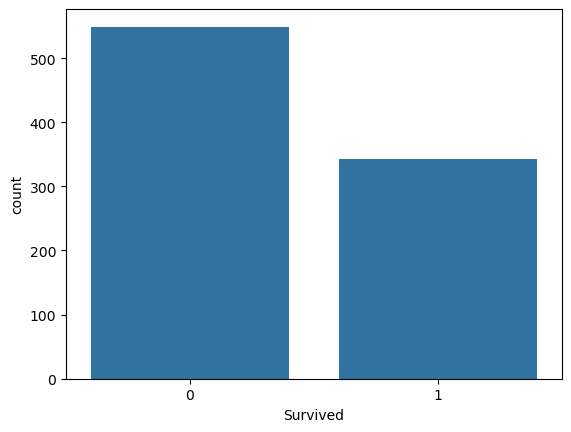

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.show()

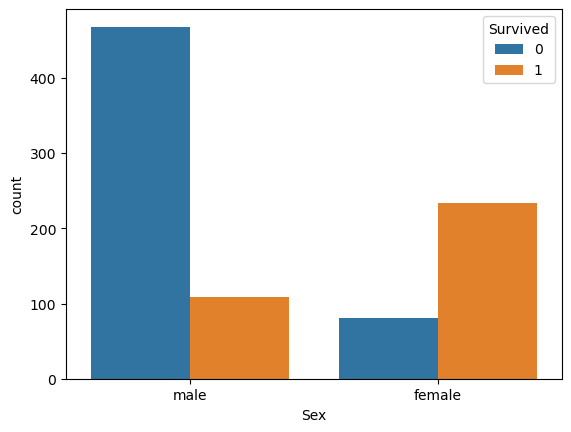

In [17]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()


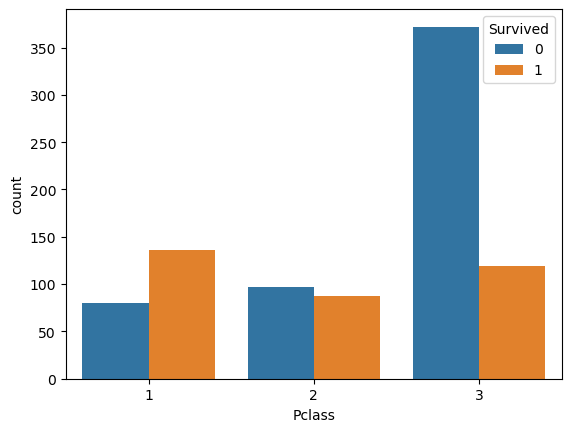

In [18]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

In [19]:
df.shape

(891, 12)

In [20]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [22]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
df = df.drop('Cabin', axis=1)

In [27]:
df['Age'].fillna(df['Age'].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [29]:
df['Embarked'].fillna(df['Embarked'].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [30]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [31]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [34]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

KeyError: "None of [Index(['Embarked'], dtype='object')] are in the [columns]"

In [35]:
 print("Available columns:", df.columns.tolist())

Available columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']


In [36]:
df = df.drop(['PassengerId','Name','Ticket'], axis=1)

In [37]:
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [38]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [43]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[90, 15],
       [19, 55]], dtype=int64)

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [19 55]]


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [47]:
rf_pred = rf.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7988826815642458


In [49]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False)

Fare          0.273568
Sex           0.268369
Age           0.253454
Pclass        0.080003
SibSp         0.054522
Parch         0.037680
Embarked_S    0.022740
Embarked_Q    0.009663
dtype: float64

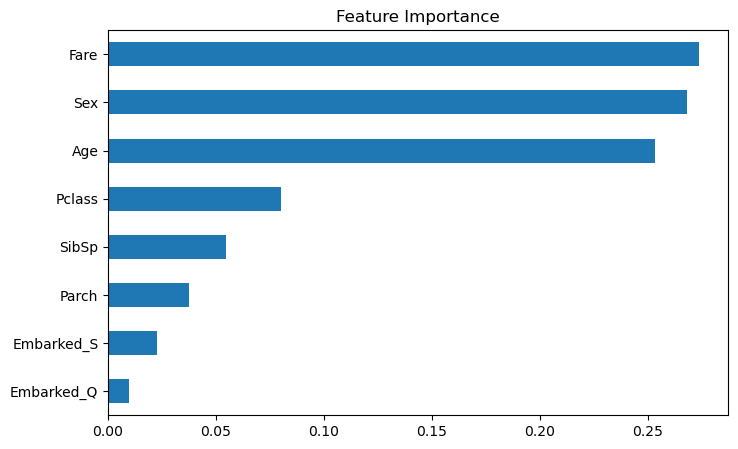

In [50]:
feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [53]:
y_pred_scaled = log_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Scaled Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_scaled))

Scaled Logistic Regression Accuracy: 0.8100558659217877


In [54]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5
)

print(scores)
print("Average Accuracy:", scores.mean())

[0.82517483 0.8041958  0.78873239 0.73943662 0.78873239]
Average Accuracy: 0.7892544075642667


In [55]:
import joblib

joblib.dump(log_model, "titanic_model.pkl")

['titanic_model.pkl']

In [56]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [57]:
df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [58]:
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [59]:
df = df.drop(['SibSp','Parch'], axis=1)

In [60]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [64]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

print("New Accuracy:", accuracy_score(y_test, y_pred))

New Accuracy: 0.7988826815642458


In [65]:
importance = pd.Series(
    model.coef_[0],
    index=X.columns
)

importance.sort_values()

Pclass       -0.743098
FamilySize   -0.623654
Age          -0.381931
IsAlone      -0.323520
Embarked_S   -0.166187
Embarked_Q   -0.035817
Fare          0.116713
Sex           1.256859
dtype: float64

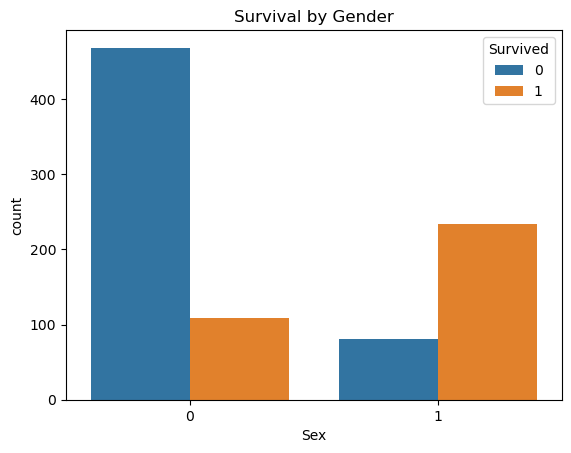

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")
plt.show()

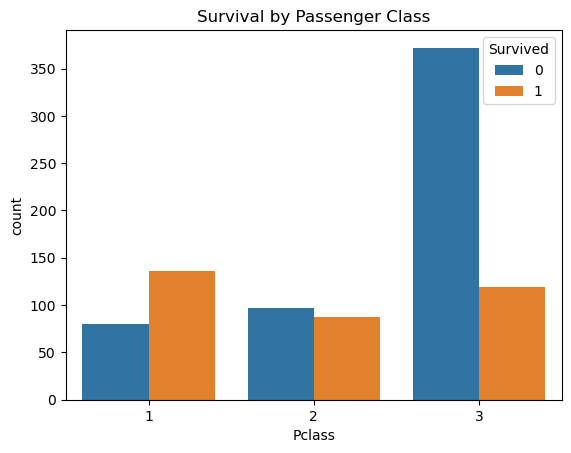

In [67]:
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")
plt.show()

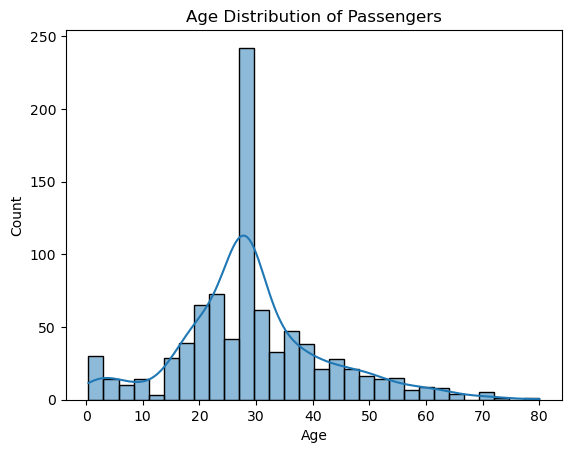

In [68]:
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.show()

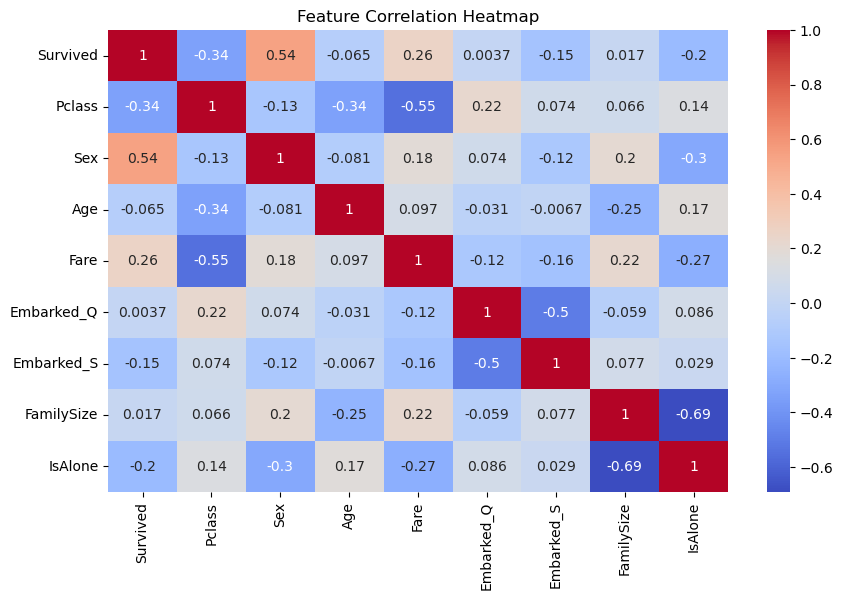

In [69]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [71]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(n_estimators=100)

}

In [72]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

print(results)

{'Logistic Regression': 0.7988826815642458, 'Decision Tree': 0.7821229050279329, 'Random Forest': 0.8379888268156425}


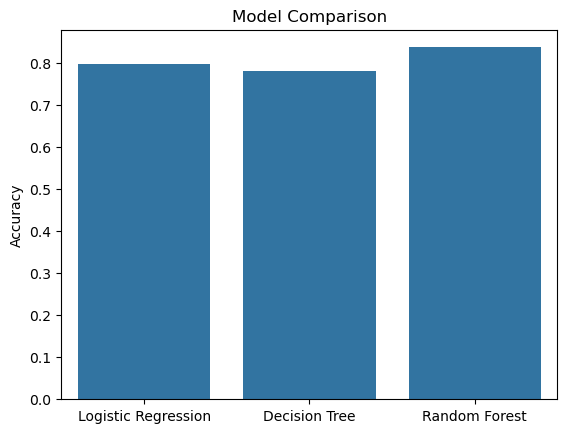

In [73]:
sns.barplot(x=list(results.keys()), y=list(results.values()))

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()